In [4]:
# 0) SETUP
import os, time, math, itertools, numpy as np, pandas as pd
from sqlalchemy import create_engine, text

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from scipy import sparse
import joblib
import warnings
warnings.filterwarnings("ignore")

# Conexión
PG = dict(
    host=os.getenv("PG_HOST","postgres"),
    port=int(os.getenv("PG_PORT","5432")),
    db=os.getenv("PG_DB","nyc_taxi"),
    user=os.getenv("PG_USER","postgres"),
    pw=os.getenv("PG_PASSWORD","postgres"),
)
ENGINE = create_engine(f"postgresql+psycopg2://{PG['user']}:{PG['pw']}@{PG['host']}:{PG['port']}/{PG['db']}")

# Params generales
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
CHUNKSIZE = 200_000       # baja a 100k si ves RAM alta
Y_RANGE   = (2015, 2025)  # defensivo; no se usará en filtros de folds (la vista ya lo aplica)
TARGET = "total_amount"

# Definición de features (pickup-only)
NUM_COLS = ["trip_distance","passenger_count","pickup_hour","pickup_dow","month","year","is_peak_hour","is_weekend"]
CAT_COLS = ["service","vendor_id","ratecode_id","pu_borough","pu_zone"]

def prep_min(df: pd.DataFrame) -> pd.DataFrame:
    """Limpieza mínima consistente antes de transformar/entrenar."""
    df = df.copy()
    df = df[df[TARGET] >= 0]
    for c in ["trip_distance","passenger_count","pickup_hour","pickup_dow","month","year","is_peak_hour","is_weekend"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["trip_distance", TARGET])
    for c in CAT_COLS:
        df[c] = df[c].astype("category")
    return df  


In [5]:
from sqlalchemy import text

CREATE_FOLDS = """
    CREATE OR REPLACE VIEW analytics.obt_trips_folds AS
SELECT
  service,
  vendor_id,
  EXTRACT(YEAR  FROM pickup_ts)::int  AS year,
  EXTRACT(MONTH FROM pickup_ts)::int  AS month,
  EXTRACT(DOW   FROM pickup_ts)::int  AS pickup_dow,
  EXTRACT(HOUR  FROM pickup_ts)::int  AS pickup_hour,
  passenger_count,
  trip_distance,
  ratecode_id,
  pu_borough,
  pu_zone,
  total_amount,
  -- flags pickup
  (EXTRACT(HOUR FROM pickup_ts)::int IN (7,8,9,16,17,18))::int AS is_peak_hour,
  (EXTRACT(DOW  FROM pickup_ts)::int IN (5,6))::int AS is_weekend,
  -- split determinístico 0..9 (hash solo de señales de pickup; evita leakage)
  (
    ABS((
      'x' || SUBSTR(
        MD5(
          CONCAT_WS('-',
            service,
            vendor_id::text,
            COALESCE(pu_borough,''),
            COALESCE(pu_zone,''),
            (EXTRACT(YEAR  FROM pickup_ts)::int)::text,
            (EXTRACT(MONTH FROM pickup_ts)::int)::text,
            (EXTRACT(DOW   FROM pickup_ts)::int)::text,
            (EXTRACT(HOUR  FROM pickup_ts)::int)::text
          )
        ),
        1, 8
      )
    )::bit(32)::int) % 10
  ) AS fold
FROM analytics.obt_trips
WHERE year BETWEEN 2015 AND 2025
  AND month BETWEEN 1 AND 12;

"""

with ENGINE.begin() as con:
    con.execute(text(CREATE_FOLDS))

print("✅ Vista analytics.obt_trips_folds lista (folds 0..9).")


✅ Vista analytics.obt_trips_folds lista (folds 0..9).


Muestra EDA: (200000, 15)

Nulos por columna:
 service            0
vendor_id          0
year               0
month              0
pickup_dow         0
pickup_hour        0
passenger_count    0
trip_distance      0
ratecode_id        0
pu_borough         0
pu_zone            0
total_amount       0
is_peak_hour       0
is_weekend         0
fold               0
dtype: int64

Cardinalidad categórica:
service: 2
vendor_id: 2
ratecode_id: 7
pu_borough: 8
pu_zone: 234


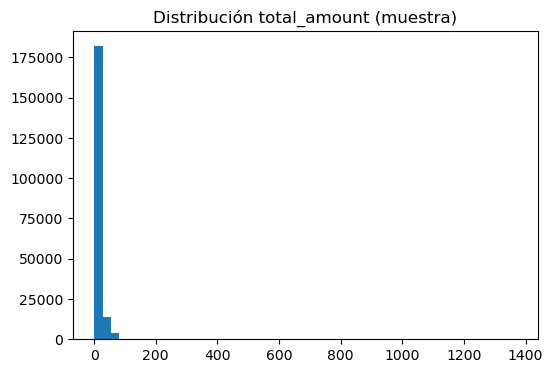

In [6]:
# 2) EDA: tomamos ~2% aleatorio
try:
    SQL_EDA = text("""
    SELECT * FROM analytics.obt_trips_folds
    TABLESAMPLE SYSTEM (2) REPEATABLE (42)
    """)
    df_eda = pd.read_sql_query(SQL_EDA, ENGINE)
except Exception:
    SQL_EDA = text("""
    SELECT * FROM analytics.obt_trips_folds
    ORDER BY random() LIMIT 200000
    """)
    df_eda = pd.read_sql_query(SQL_EDA, ENGINE)

print("Muestra EDA:", df_eda.shape)
print("\nNulos por columna:\n", df_eda.isna().sum())

print("\nCardinalidad categórica:")
for c in ["service","vendor_id","ratecode_id","pu_borough","pu_zone"]:
    print(f"{c}: {df_eda[c].nunique()}")

# Distribución del target (matplotlib estándar para evitar overhead)
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.hist(df_eda["total_amount"], bins=50)
plt.title("Distribución total_amount (muestra)")
plt.show()


In [7]:
# Reducimos cardinalidad de pu_zone (Top-K en la muestra EDA)
TOP_K_ZONES = 100
top_zones = df_eda["pu_zone"].value_counts().head(TOP_K_ZONES).index

def map_top_zone(s):
    return s if s in top_zones else "Other"

df_eda = prep_min(df_eda)
df_eda["pu_zone"] = df_eda["pu_zone"].apply(map_top_zone).astype("category")

# Preprocesador: polinomios (en num selectas) + escala + OHE
POLY_NUM_COLS = ["trip_distance","pickup_hour"]
remain_num = [c for c in NUM_COLS if c not in POLY_NUM_COLS]

num_transformer = ColumnTransformer([
    ("scale_rest", StandardScaler(), remain_num),
    ("poly_block", Pipeline([
        ("poly",  PolynomialFeatures(degree=2, include_bias=False)),
        ("scale", StandardScaler())
    ]), POLY_NUM_COLS)
])

cat_transformer = OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=500, sparse_output=True)

pre = ColumnTransformer([
    ("num", num_transformer, NUM_COLS),
    ("cat", cat_transformer, CAT_COLS),
], remainder="drop")

X_fit = pre.fit_transform(df_eda[NUM_COLS + CAT_COLS])
print("Preprocesador ajustado. X_fit shape:", X_fit.shape)


Preprocesador ajustado. X_fit shape: (200000, 97)


In [8]:
SQL_TRAIN = text("""SELECT * FROM analytics.obt_trips_folds WHERE fold BETWEEN 0 AND 7""")
SQL_VAL   = text("""SELECT * FROM analytics.obt_trips_folds WHERE fold = 8""")
SQL_TEST  = text("""SELECT * FROM analytics.obt_trips_folds WHERE fold = 9""")

def iter_chunks(sql_text, chunksize=CHUNKSIZE):
    for ch in pd.read_sql_query(sql_text, ENGINE, chunksize=chunksize):
        ch = prep_min(ch)
        ch["pu_zone"] = ch["pu_zone"].apply(map_top_zone).astype("category")
        Xc = pre.transform(ch[NUM_COLS + CAT_COLS])
        yc = ch[TARGET].to_numpy()
        yield Xc, yc


In [9]:
# Optimizadores simple-SGD (soporta scipy.sparse)
class SGDBase:
    def __init__(self, alpha=1e-4, l1_ratio=0.0, lr=0.01, epochs=1, penalty="none"):
        self.alpha = float(alpha)
        self.l1_ratio = float(l1_ratio)
        self.lr = float(lr)
        self.epochs = int(epochs)
        self.penalty = penalty  # none|l1|l2|elasticnet
        self.w = None

    def _grad(self, x, err):
        # grad MSE: -2 x err
        g = (-2.0) * err * x
        # regularización
        if self.penalty in ("l2","elasticnet"):
            g = g + 2.0 * self.alpha * (1.0 if self.penalty=="l2" else (1.0 - self.l1_ratio)) * self.w
        return g

    def _l1_step(self):
        if self.penalty in ("l1","elasticnet"):
            lam = self.alpha if self.penalty=="l1" else self.alpha * self.l1_ratio
            # soft-thresholding
            self.w = np.sign(self.w) * np.maximum(0.0, np.abs(self.w) - self.lr * lam)

    def partial_fit(self, X, y):
        if sparse.issparse(X):
            X = X.tocsr()
            n, d = X.shape
            if self.w is None:
                self.w = np.zeros(d, dtype=np.float64)
            for _ in range(self.epochs):
                for i in range(n):
                    row = X.getrow(i)
                    xi = row.toarray().ravel()
                    yi = y[i]
                    err = yi - xi.dot(self.w)
                    grad = self._grad(xi, err)
                    self.w -= self.lr * grad
                    self._l1_step()
        else:
            n, d = X.shape
            if self.w is None:
                self.w = np.zeros(d, dtype=np.float64)
            for _ in range(self.epochs):
                for i in range(n):
                    xi = X[i]
                    yi = y[i]
                    err = yi - xi.dot(self.w)
                    grad = self._grad(xi, err)
                    self.w -= self.lr * grad
                    self._l1_step()
        return self

    def predict(self, X):
        if sparse.issparse(X):
            return X @ self.w
        return X.dot(self.w)

def train_scratch(model: SGDBase, sql_train, sql_val=None, max_chunks=None):
    t0 = time.time()
    n_rows = 0
    for j, (Xc, yc) in enumerate(iter_chunks(sql_train), start=1):
        model.partial_fit(Xc, yc)
        n_rows += len(yc)
        if max_chunks and j >= max_chunks: break
        if j % 5 == 0: print(f"[from-scratch] chunks {j}, rows {n_rows:,}")
    train_time = time.time() - t0

    metrics = {}
    if sql_val is not None:
        # validación: cargamos todo val (enero 2015 es pequeño; si no, pon chunks o LIMIT)
        Xv_list, yv_list = [], []
        for Xv, yv in iter_chunks(sql_val, chunksize=100_000):
            Xv_list.append(Xv); yv_list.append(yv)
        Xv = sparse.vstack(Xv_list) if any(sparse.issparse(x) for x in Xv_list) else np.vstack(Xv_list)
        yv = np.concatenate(yv_list)
        yhat = model.predict(Xv)
        metrics = dict(
            rmse = mean_squared_error(yv, yhat, squared=False),
            mae  = mean_absolute_error(yv, yhat),
            r2   = r2_score(yv, yhat),
            n_val = len(yv)
        )
    return model, train_time, n_rows, metrics

# Definimos 4 variantes
def make_models_scratch():
    return {
        "sgd_mse": SGDBase(alpha=1e-4, lr=0.01, epochs=1, penalty="none"),
        "ridge"  : SGDBase(alpha=1e-3, lr=0.01, epochs=1, penalty="l2"),
        "lasso"  : SGDBase(alpha=1e-3, lr=0.01, epochs=1, penalty="l1"),
        "enet"   : SGDBase(alpha=1e-3, l1_ratio=0.3, lr=0.01, epochs=1, penalty="elasticnet"),
    }

# Grid simple para los 4
SCRATCH_GRID = {
    "sgd_mse": {"alpha":[1e-4,1e-3], "lr":[0.01,0.005]},
    "ridge"  : {"alpha":[1e-3,1e-2], "lr":[0.01,0.005]},
    "lasso"  : {"alpha":[1e-3,1e-2], "lr":[0.01,0.005]},
    "enet"   : {"alpha":[1e-3,1e-2], "l1_ratio":[0.2,0.5], "lr":[0.01,0.005]},
}


In [11]:
results_scratch = []
best_models_scratch = {}

for name, grid in SCRATCH_GRID.items():
    keys = list(grid.keys())
    for vals in itertools.product(*[grid[k] for k in keys]):
        params = dict(zip(keys, vals))
        m = make_models_scratch()[name]
        # aplicar params
        for k,v in params.items(): setattr(m, k, v)
        print(f"\n>> FROM-SCRATCH {name} params={params}")
        model, t_train, n_rows, metr = train_scratch(m, SQL_TRAIN, SQL_VAL)
        row = dict(model=name, **params, time=t_train, n_train=n_rows, **metr)
        results_scratch.append(row)

# Elegimos el mejor por RMSE
df_scratch = pd.DataFrame(results_scratch).sort_values("rmse")
df_scratch.head(10)
best_name = df_scratch.iloc[0]["model"]
best_params = {k:v for k,v in df_scratch.iloc[0].items() if k in SCRATCH_GRID.get(best_name, {})}
print("🏆 mejor from-scratch:", best_name, best_params)

# Reentrenar ganador en Train+Val (fold 0..8) para test
SQL_TRAINVAL = text("""SELECT * FROM analytics.obt_trips_folds WHERE fold BETWEEN 0 AND 8""")
m_final = make_models_scratch()[best_name]
for k,v in best_params.items(): setattr(m_final, k, v)
_ = train_scratch(m_final, SQL_TRAINVAL, sql_val=None)
# Eval test
Xte_list, yte_list = [], []
for Xt, yt in iter_chunks(SQL_TEST, chunksize=600_000):
    Xte_list.append(Xt); yte_list.append(yt)
Xte = sparse.vstack(Xte_list) if any(sparse.issparse(x) for x in Xte_list) else np.vstack(Xte_list)
yte = np.concatenate(yte_list)
yhat_te = m_final.predict(Xte)
metrics_test_scratch = dict(
    rmse = mean_squared_error(yte, yhat_te, squared=False),
    mae  = mean_absolute_error(yte, yhat_te),
    r2   = r2_score(yte, yhat_te),
    n_test = len(yte)
)
metrics_test_scratch



>> FROM-SCRATCH sgd_mse params={'alpha': 0.0001, 'lr': 0.01}
[from-scratch] chunks 5, rows 1,000,000
[from-scratch] chunks 10, rows 2,000,000
[from-scratch] chunks 15, rows 3,000,000
[from-scratch] chunks 20, rows 4,000,000
[from-scratch] chunks 25, rows 5,000,000
[from-scratch] chunks 30, rows 6,000,000
[from-scratch] chunks 35, rows 7,000,000
[from-scratch] chunks 40, rows 8,000,000
[from-scratch] chunks 45, rows 9,000,000
[from-scratch] chunks 50, rows 10,000,000
[from-scratch] chunks 55, rows 11,000,000

>> FROM-SCRATCH sgd_mse params={'alpha': 0.0001, 'lr': 0.005}
[from-scratch] chunks 5, rows 1,000,000
[from-scratch] chunks 10, rows 2,000,000
[from-scratch] chunks 15, rows 3,000,000
[from-scratch] chunks 20, rows 4,000,000
[from-scratch] chunks 25, rows 5,000,000
[from-scratch] chunks 30, rows 6,000,000
[from-scratch] chunks 35, rows 7,000,000
[from-scratch] chunks 40, rows 8,000,000
[from-scratch] chunks 45, rows 9,000,000
[from-scratch] chunks 50, rows 10,000,000
[from-scratch

{'rmse': 813.9899317891721,
 'mae': 23.20490289094847,
 'r2': -0.0009760448677522682,
 'n_test': 1480875}

In [12]:
from sklearn.linear_model import SGDRegressor, Ridge, Lasso, ElasticNet
N_TRAIN = 400_000
N_VAL   = 200_000
N_TEST  = 200_000

def load_sample(sql_base, limit):
    # Muestreo reproducible desde SQL
    sql = text(f"""
    WITH base AS ({sql_base.text})
    SELECT * FROM base                                                                                                                                
    ORDER BY random() LIMIT :n
    """)
    df_s = pd.read_sql_query(sql, ENGINE, params={"n": limit})
    df_s = prep_min(df_s)
    df_s["pu_zone"] = df_s["pu_zone"].apply(map_top_zone).astype("category")
    Xs = pre.transform(df_s[NUM_COLS + CAT_COLS])
    ys = df_s[TARGET].to_numpy()
    return Xs, ys

Xtr_s, ytr_s = load_sample(SQL_TRAIN, N_TRAIN) 
Xva_s, yva_s = load_sample(SQL_VAL,   N_VAL)
Xte_s, yte_s = load_sample(SQL_TEST,  N_TEST)

models_skl = {
    "sgd_skl"  : SGDRegressor(loss="squared_error", penalty="elasticnet", alpha=1e-4, l1_ratio=0.15, max_iter=2000, tol=1e-3, random_state=RANDOM_SEED),
    "ridge_skl": Ridge(alpha=1.0, random_state=RANDOM_SEED),
    "lasso_skl": Lasso(alpha=0.001, max_iter=5000, random_state=RANDOM_SEED),
    "enet_skl" : ElasticNet(alpha=0.001, l1_ratio=0.3, max_iter=5000, random_state=RANDOM_SEED),
}

results_skl = []
for name, mdl in models_skl.items():
    t0 = time.time()
    mdl.fit(Xtr_s, ytr_s)
    tr_time = time.time()-t0
    yhat = mdl.predict(Xva_s)
    results_skl.append(dict(
        model=name,
        rmse=mean_squared_error(yva_s, yhat, squared=False),
        mae=mean_absolute_error(yva_s, yhat),
        r2=r2_score(yva_s, yhat),
        time=tr_time,
        n_coef = (mdl.coef_.size if hasattr(mdl, "coef_") else (mdl.n_features_in_ if hasattr(mdl,"n_features_in_") else None))
    ))
df_skl = pd.DataFrame(results_skl).sort_values("rmse")
df_skl


,model,rmse,mae,r2,time,n_coef
2,lasso_skl,1.123550e+01,5.762446e+00,3.611845e-01,890.849499,97
3,enet_skl,1.127355e+01,5.787067e+00,3.568505e-01,960.298026,97
1,ridge_skl,8.706651e+02,8.638919e+00,-3.835126e+03,8.834630,97
0,sgd_skl,6.741426e+11,2.709123e+09,-2.299822e+21,0.696825,97


In [13]:
# Test de sklearn
rows_skl_test = []
for name, mdl in models_skl.items():
    yhat_te = mdl.predict(Xte_s)
    rows_skl_test.append(dict(
        model=name+"_test",
        rmse=mean_squared_error(yte_s, yhat_te, squared=False),
        mae=mean_absolute_error(yte_s, yhat_te),
        r2=r2_score(yte_s, yhat_te),
        time=None, n_coef=None
    ))
df_skl_test = pd.DataFrame(rows_skl_test)

# Test del ganador from-scratch ya lo calculamos antes en metrics_test_scratch
df_fscratch_test = pd.DataFrame([{"model": best_name+"_test", **metrics_test_scratch}])

# Unimos tablas (Validación)
df_val_all = pd.concat([df_scratch[["model","rmse","mae","r2","time"]], df_skl[["model","rmse","mae","r2","time"]]], ignore_index=True)
print("== Validación ==")
display(df_val_all.sort_values("rmse").head(10))

print("== Test ==")
display(pd.concat([df_skl_test, df_fscratch_test], ignore_index=True).sort_values("rmse"))


== Validación ==


,model,rmse,mae,r2,time
20,lasso_skl,1.123550e+01,5.762446e+00,3.611845e-01,890.849499
21,enet_skl,1.127355e+01,5.787067e+00,3.568505e-01,960.298026
0,ridge,2.730028e+01,2.243302e+01,-3.666882e+00,411.715121
1,enet,2.806080e+01,2.315832e+01,-3.930519e+00,475.637777
2,ridge,2.843125e+01,2.357590e+01,-4.061560e+00,410.928018
3,enet,2.935378e+01,2.441003e+01,-4.395364e+00,471.954868
4,enet,3.076571e+01,2.576910e+01,-4.926884e+00,455.739961
5,enet,3.135720e+01,2.615472e+01,-5.156972e+00,469.611840
22,ridge_skl,8.706651e+02,8.638919e+00,-3.835126e+03,8.834630
23,sgd_skl,6.741426e+11,2.709123e+09,-2.299822e+21,0.696825


== Test ==


,model,rmse,mae,r2,time,n_coef,n_test
1,ridge_skl_test,8.386973e+00,5.348891e+00,5.469526e-01,None,None,NaN
2,lasso_skl_test,8.971105e+00,5.755331e+00,4.816478e-01,None,None,NaN
3,enet_skl_test,8.986213e+00,5.771465e+00,4.799005e-01,None,None,NaN
4,ridge_test,8.139899e+02,2.320490e+01,-9.760449e-04,NaN,NaN,1480875.0
0,sgd_skl_test,3.285028e+08,2.021195e+08,-6.950422e+14,None,None,NaN


In [14]:
# Elegimos por menor RMSE en validación entre todos
df_all_val = df_val_all.sort_values("rmse")
winner = df_all_val.iloc[0]["model"]
print("🏆 Ganador global (validación):", winner)

# Guardamos artefactos del pipeline ganador
os.makedirs("artifacts", exist_ok=True)
joblib.dump(pre, "artifacts/preprocessor.joblib")

if winner in models_skl:
    joblib.dump(models_skl[winner], f"artifacts/model_{winner}.joblib")
else:
    # from-scratch ganador: guardamos sus pesos finales (entrenados en train+val)
    np.save("artifacts/model_fscratch_weights.npy", m_final.w)

print("✅ Artefactos guardados en ./artifacts")


🏆 Ganador global (validación): lasso_skl
✅ Artefactos guardados en ./artifacts


In [15]:
# Usamos la muestra de validación sklearn (Xva_s, yva_s) por practicidad
if winner in models_skl:
    model_diag = models_skl[winner]
else:
    model_diag = m_final

yhat_val = model_diag.predict(Xva_s)
res = yva_s - yhat_val

print("RMSE/MAE/R2:", 
      mean_squared_error(yva_s, yhat_val, squared=False),
      mean_absolute_error(yva_s, yhat_val),
      r2_score(yva_s, yhat_val))

# Top-errores absolutos
idx_top = np.argsort(np.abs(res))[-10:]
print("Top 10 |error| en validación (muestra):")
print(np.c_[yva_s[idx_top], yhat_val[idx_top], res[idx_top]])


RMSE/MAE/R2: 11.23550068599635 5.762445813248659 0.3611845349649754
Top 10 |error| en validación (muestra):
[[ 274.35         41.76055495  232.58944505]
 [ 295.3          46.72519427  248.57480573]
 [ 295.3          41.33521269  253.96478731]
 [ 323.55         66.43913728  257.11086272]
 [  19.8         295.91734984 -276.11734984]
 [ 344.27         66.16943499  278.10056501]
 [   8.8         301.8540095  -293.0540095 ]
 [ 405.3          42.32540429  362.97459571]
 [ 584.63         17.72803487  566.90196513]
 [3006.35         17.22114275 2989.12885725]]


In [16]:
print("Features numéricas:", NUM_COLS)
print("Features categóricas:", CAT_COLS)

# muestra de 10 filas con solo columnas de interés
cols_show = NUM_COLS + CAT_COLS + [TARGET]
print("\nMuestra (10 filas):")
display(pd.read_sql_query(
    "SELECT " + ",".join(cols_show) + " FROM analytics.obt_trips_folds LIMIT 10",
    ENGINE
))


Features numéricas: ['trip_distance', 'passenger_count', 'pickup_hour', 'pickup_dow', 'month', 'year', 'is_peak_hour', 'is_weekend']
Features categóricas: ['service', 'vendor_id', 'ratecode_id', 'pu_borough', 'pu_zone']

Muestra (10 filas):


,trip_distance,passenger_count,pickup_hour,pickup_dow,month,year,is_peak_hour,is_weekend,service,vendor_id,ratecode_id,pu_borough,pu_zone,total_amount
0,2.26,5,19,6,1,2015,0,1,yellow,2,1,Manhattan,Manhattan Valley,14.16
1,1.88,5,19,6,1,2015,0,1,yellow,2,1,Manhattan,Lincoln Square East,11.76
2,5.00,5,19,6,1,2015,0,1,yellow,2,1,Manhattan,Lenox Hill West,19.30
3,4.67,5,19,6,1,2015,0,1,yellow,2,1,Manhattan,East Village,24.96
4,6.13,5,19,6,1,2015,0,1,yellow,2,1,Manhattan,Yorkville West,28.40
5,2.02,2,19,6,1,2015,0,1,yellow,2,1,Manhattan,Upper West Side North,12.96
6,1.07,2,19,6,1,2015,0,1,yellow,2,1,Manhattan,Upper East Side South,9.30
7,19.58,1,19,6,1,2015,0,1,yellow,2,2,Manhattan,Meatpacking/West Village West,68.13
8,6.44,3,19,6,1,2015,0,1,yellow,2,1,Manhattan,Yorkville West,28.80
9,1.50,2,19,6,1,2015,0,1,yellow,1,1,Manhattan,Greenwich Village South,8.30


In [17]:
import pandas as pd

folds_df = pd.read_sql_query("""
SELECT fold, COUNT(*) AS n
FROM analytics.obt_trips_folds
GROUP BY fold
ORDER BY fold;
""", ENGINE)

print("Conteo por fold (0..9):")
display(folds_df)

print("Train = folds 0..7, Val = 8, Test = 9")
print("Train rows:", folds_df.query("fold <= 7")["n"].sum())
print("Val rows  :", folds_df.query("fold == 8")["n"].sum())
print("Test rows :", folds_df.query("fold == 9")["n"].sum())


Conteo por fold (0..9):


,fold,n
0,0,1371007
1,1,1466810
2,2,1344779
3,3,1388019
4,4,1455577
5,5,1503494
6,6,1421016
7,7,1416912
8,8,1394438
9,9,1480875


Train = folds 0..7, Val = 8, Test = 9
Train rows: 11367614
Val rows  : 1394438
Test rows : 1480875


In [18]:
# Dimensionalidad y categorías del OHE ya ajustado
print("Preprocesador ajustado ✅")
try:
    ohe = [t for name,t,cols in pre.transformers_ if name=="cat"][0]
    cats = getattr(ohe, "categories_", None)
    if cats is not None:
        print("Categorías por variable categórica:")
        for name, cats_i in zip(CAT_COLS, cats):
            print(f"  - {name}: {len(cats_i)} categorías")
except Exception as e:
    print("No se pudo inspeccionar OHE:", e)

# tamaño de la matriz de diseño en la muestra EDA (solo para mostrar)
from scipy import sparse
_X_show = pre.transform(df_eda[NUM_COLS + CAT_COLS].head(1000))
shape = _X_show.shape
is_sparse = sparse.issparse(_X_show)
print(f"Matriz de diseño (preview): shape={shape}, sparse={is_sparse}")


Preprocesador ajustado ✅
Categorías por variable categórica:
  - service: 2 categorías
  - vendor_id: 2 categorías
  - ratecode_id: 7 categorías
  - pu_borough: 8 categorías
  - pu_zone: 101 categorías
Matriz de diseño (preview): shape=(1000, 97), sparse=True


In [19]:
import pandas as pd

print("== Validación (todos los modelos) ==")
if "df_val_all" in globals():
    display(df_val_all.sort_values("rmse").reset_index(drop=True))
else:
    print("df_val_all no existe en esta sesión.")

print("\n== Test (sklearn vs from-scratch ganador) ==")
if "df_skl_test" in globals() and "df_fscratch_test" in globals():
    display(pd.concat([df_skl_test, df_fscratch_test], ignore_index=True).sort_values("rmse").reset_index(drop=True))
else:
    print("Tablas de test no disponibles aún.")

print("\nGanador (validación):", globals().get("winner", "<aún no definido>"))


== Validación (todos los modelos) ==


,model,rmse,mae,r2,time
0,lasso_skl,1.123550e+01,5.762446e+00,3.611845e-01,890.849499
1,enet_skl,1.127355e+01,5.787067e+00,3.568505e-01,960.298026
2,ridge,2.730028e+01,2.243302e+01,-3.666882e+00,411.715121
3,enet,2.806080e+01,2.315832e+01,-3.930519e+00,475.637777
4,ridge,2.843125e+01,2.357590e+01,-4.061560e+00,410.928018
5,enet,2.935378e+01,2.441003e+01,-4.395364e+00,471.954868
6,enet,3.076571e+01,2.576910e+01,-4.926884e+00,455.739961
7,enet,3.135720e+01,2.615472e+01,-5.156972e+00,469.611840
8,ridge_skl,8.706651e+02,8.638919e+00,-3.835126e+03,8.834630
9,sgd_skl,6.741426e+11,2.709123e+09,-2.299822e+21,0.696825



== Test (sklearn vs from-scratch ganador) ==


,model,rmse,mae,r2,time,n_coef,n_test
0,ridge_skl_test,8.386973e+00,5.348891e+00,5.469526e-01,None,None,NaN
1,lasso_skl_test,8.971105e+00,5.755331e+00,4.816478e-01,None,None,NaN
2,enet_skl_test,8.986213e+00,5.771465e+00,4.799005e-01,None,None,NaN
3,ridge_test,8.139899e+02,2.320490e+01,-9.760449e-04,NaN,NaN,1480875.0
4,sgd_skl_test,3.285028e+08,2.021195e+08,-6.950422e+14,None,None,NaN



Ganador (validación): lasso_skl


RMSE/MAE/R² (val): 11.23550068599635 5.762445813248659 0.3611845349649754


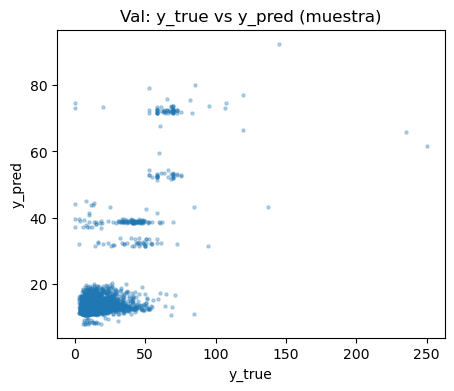

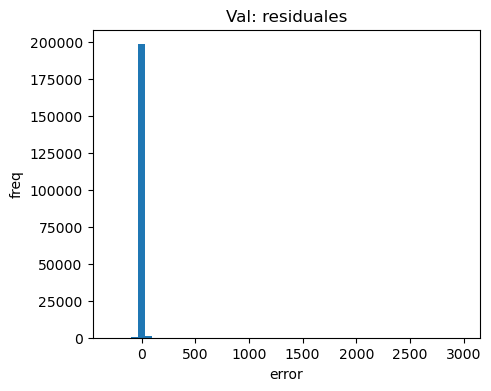

In [20]:
import numpy as np

if "yva_s" in globals() and "Xva_s" in globals():
    # usa el ganador ya entrenado si existe; si no, toma Ridge sklearn como demo
    if "winner" in globals() and winner in globals().get("models_skl", {}):
        model_diag = models_skl[winner]
    elif "m_final" in globals():
        model_diag = m_final
    else:
        from sklearn.linear_model import Ridge
        model_diag = Ridge().fit(Xtr_s, ytr_s)

    yhat_val = model_diag.predict(Xva_s)
    res = yva_s - yhat_val

    print("RMSE/MAE/R² (val):",
          mean_squared_error(yva_s, yhat_val, squared=False),
          mean_absolute_error(yva_s, yhat_val),
          r2_score(yva_s, yhat_val))

    import matplotlib.pyplot as plt
    plt.figure(figsize=(5,4)); plt.scatter(yva_s[:5000], yhat_val[:5000], s=5, alpha=0.3)
    plt.title("Val: y_true vs y_pred (muestra)"); plt.xlabel("y_true"); plt.ylabel("y_pred"); plt.show()

    plt.figure(figsize=(5,4)); plt.hist(res, bins=50); plt.title("Val: residuales"); plt.xlabel("error"); plt.ylabel("freq"); plt.show()
else:
    print("No hay Xva_s / yva_s en memoria para diagnóstico. Ejecuta primero la sección sklearn.")
